In [23]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,mean_absolute_error, mean_squared_error, accuracy_score, precision_score, roc_auc_score, recall_score, f1_score, make_scorer

Loading of Dataset

In [24]:
data = pd.read_csv("completed_dataset_for_IS_project_25.csv")

Dataset's basic info

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52656 entries, 0 to 52655
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   52656 non-null  int64  
 1   MONTH                  52656 non-null  int64  
 2   DAY                    52656 non-null  int64  
 3   LAT                    52656 non-null  float64
 4   LONG                   52656 non-null  float64
 5   WIND_KTS               52656 non-null  int64  
 6   PRESSURE               52656 non-null  int64  
 7   CAT                    52656 non-null  object 
 8   Shape_Leng             52656 non-null  float64
 9   Country                52656 non-null  object 
 10  CO2 emission (Tons)    52656 non-null  float64
 11  Jan                    52656 non-null  float64
 12  Feb                    52656 non-null  float64
 13  Mar                    52656 non-null  float64
 14  Apr                    52656 non-null  float64
 15  Ma

Creating a column to identify if a tropical storm occured or not based on the intensity levels created in the feature engineering

In [26]:
data['isTropicalStorm'] = (data['Storm Intensity Label'] > 1).astype(int)

Identifying any Potential inbalances in predicted column

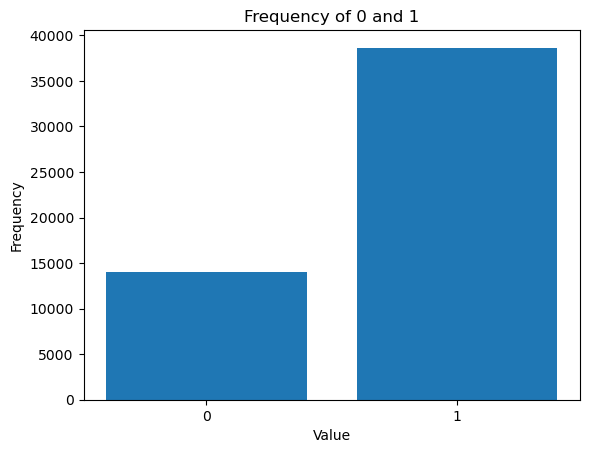

In [27]:
import matplotlib.pyplot as plt

binary_classes = data['isTropicalStorm'].values
unique, counts = np.unique(binary_classes, return_counts= True)

plt.bar(unique,counts, tick_label=['0', '1'])
plt.title('Frequency of 0 and 1')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks([0, 1])  # Ensure x-axis ticks are at 0 and 1
plt.show()

Set up target variable

In [28]:
X = data.drop(columns=['isTropicalStorm', 'Country','CAT', 'Storm Intensity', 'Storm Intensity Label'], axis=1)
# Target for occurrence prediction
y_occurrence = data['isTropicalStorm']
# Target for intensity prediction
y_intensity = data['Storm Intensity Label']

Split data into 70% for Training and 15% for Validation and 15% for Testing

In [29]:
X_train_occ, X_temp_occ, y_train_occ, y_temp_occ = train_test_split(X, y_occurrence, test_size=0.3, random_state=42, stratify=y_occurrence)
X_val_occ, X_test_occ, y_val_occ, y_test_occ = train_test_split(X_temp_occ, y_temp_occ, test_size=0.5, random_state=42, stratify=y_temp_occ)

# Tropical Storm Occurence Prediction

Pipeline initialized to allow scaling to ensure fair weighting as well as initialize logistic regression classifier

In [30]:
pipeline_occ = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=16)) # You can try other classifiers
])

Grid for Hyperparameters
- penalty for overfitting and sparsity of data
- C for regularization strength of data with smaller values giving stronger regularization
- solver: saga for large datasets, liblinear for small datasets

In [31]:
param_grid_occ = {
    'classifier__penalty': ['l1', 'l2'],
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'saga']
}

Custom F1 scorers to evaluate the model instead of accuracy that is misleading
Grid search initialization

In [32]:
f1_scorer_occ = make_scorer(f1_score)
grid_search_occ = GridSearchCV(pipeline_occ, param_grid_occ, cv=5, scoring=f1_scorer_occ, n_jobs=-1)

Utilizing validation set and training set to maximise learning
Grid Search to find the best hyperparameters for the model

In [33]:
full_train = np.concatenate([X_train_occ, X_val_occ])
full_labels = np.concatenate([y_train_occ, y_val_occ])

grid_search_occ.fit(full_train, full_labels)  # Now using all non-test data


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        LogisticRegression(random_state=16))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear', 'saga']},
             scoring=make_scorer(f1_score, response_method='predict'))

In [34]:
best_model_occ = grid_search_occ.best_estimator_
y_pred_occ = best_model_occ.predict(X_test_occ)

c:\Users\danie\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Evaluate the model using accuracy,precision, recall and F1 Score 

In [35]:
target_names_occ = ['Tropical Storm did not occur', 'Tropical Storm did occur']
# print(classification_report(y_test_occ, y_pred_occ, target_names=target_names_occ))

# Basic classification metrics
print(f"Accuracy: {accuracy_score(y_test_occ, y_pred_occ):.4f}")
print(f"Precision: {precision_score(y_test_occ, y_pred_occ):.4f}")
print(f"Recall: {recall_score(y_test_occ, y_pred_occ):.4f}")
print(f"F1 Score: {f1_score(y_test_occ, y_pred_occ):.4f}")

Accuracy: 0.9332
Precision: 0.9521
Recall: 0.9570
F1 Score: 0.9546


In [36]:
# 1. Check class distribution
print("Class distribution:\n", y_occurrence.value_counts(normalize=True))

Class distribution:
 isTropicalStorm
1    0.733801
0    0.266199
Name: proportion, dtype: float64


In [37]:
y_pred_proba = best_model_occ.predict_proba(X_test_occ)[:,1]
print(f"AUC-ROC: {roc_auc_score(y_test_occ, y_pred_proba):.4f}")

AUC-ROC: 0.9692


c:\Users\danie\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [38]:
# Calculate regression metrics using predicted PROBABILITIES
print(f"MSE (on probabilities): {mean_squared_error(y_test_occ, y_pred_proba):.4f}")
print(f"MAE (on probabilities): {mean_absolute_error(y_test_occ, y_pred_proba):.4f}")

MSE (on probabilities): 0.0554
MAE (on probabilities): 0.1185


In [39]:
# 3. Compare to a dummy classifier
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent').fit(X_train_occ, y_train_occ)
print("Dummy accuracy:", dummy.score(X_test_occ, y_test_occ))

Dummy accuracy: 0.7337637675655146


# Tropical Storm Intensity Prediction

Ensures the intensity model trains only where tropical storms occur by filtering to 'Storm Intensity Label' > 1

In [40]:
train_storm_indices = y_train_occ[y_train_occ == 1].index
train_storm_data = data.loc[train_storm_indices]
train_storm_data = train_storm_data[train_storm_data['Storm Intensity Label'] > 1]


For intensity classes that may not appear in small validation folds, this custom fl_score function ensures only the preset labels are scored in each fold while also accounting for class imbalance using the weighted average. 

In [41]:
def safe_weighted_f1(y_true, y_pred):
    # Get labels actually present in y_true
    present_labels = list(set(y_true))
    return f1_score(y_true, y_pred, average='weighted', labels=present_labels)

# Wrap it into a scikit-learn scorer
f1_weighted_scorer = make_scorer(safe_weighted_f1)

In [42]:
if not train_storm_data.empty:
    X_train_int = train_storm_data.drop(columns=['isTropicalStorm', 'Country', 'CAT', 'WIND_KTS', 'Wind Speed Squared', 'PRESSURE', 'Storm Intensity', 'Storm Intensity Label'])
    y_train_int = train_storm_data['Storm Intensity Label']
    
    print("Original intensity distribution:")
    print(y_train_int.value_counts().sort_index())

    # Intensity model pipeline with SMOTE to balance the imbalance in the intensity classes, while using the random forest classifier for the non-linear relationships and the standard scaler to normalize the numerical features 
    intensity_pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', 
            RandomForestClassifier(class_weight='balanced', random_state=42)
        )
    ])

    #Hyperparameter tuning to ajust tree depth and ensemble sizes for Random Forrest classifier model
    param_grid_int = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10]
    }

    # f1_weighted_scorer = make_scorer(f1_score, average='weighted')

    grid_search_int = GridSearchCV(
        intensity_pipeline,
        param_grid_int,
        cv=5,
        # scoring=make_scorer(f1_score, average='weighted'),
        scoring=f1_weighted_scorer,
        n_jobs=2,
        verbose=2,
        error_score='raise'
    )
    grid_search_int.fit(X_train_int, y_train_int)
    best_intensity_model = grid_search_int.best_estimator_
    
    #Evaluates on storms predicted by the model earlier while further filtering out the storm intensities
    predicted_storm_indices = y_test_occ[y_test_occ == 1].index
    if len(predicted_storm_indices) > 0:
        # Get true intensity labels for these storms
        y_test_intensity = data.loc[predicted_storm_indices, 'Storm Intensity Label']
        real_storms = y_test_intensity[y_test_intensity > 1]
        
        if len(real_storms) > 0:
            cols_to_drop = ['WIND_KTS', 'Wind Speed Squared', 'PRESSURE']
            X_test_storms = X_test_occ.loc[real_storms.index].drop(columns=cols_to_drop)
            # X_test_storms = X_test_occ.loc[real_storms.index]

            # Final Evaluation to show how model performed for classifying the different levels of a tropical storm
            y_pred_intensity = best_intensity_model.predict(X_test_storms)
            
            print("\nTrue intensity distribution in test set:")
            print(real_storms.value_counts().sort_index())
            
            print("\nIntensity Prediction Report:")
            print(classification_report(real_storms, y_pred_intensity))
        else:
            print("\nNo actual storms with intensity >1 in test set predictions")
    else:
        print("\nNo storms predicted in test set")
else:
    print("No training data with intensity >1 available")


Original intensity distribution:
Storm Intensity Label
2    15275
3     6281
4     2754
5     1653
6      961
7      123
Name: count, dtype: int64
Fitting 5 folds for each of 4 candidates, totalling 20 fits

True intensity distribution in test set:
Storm Intensity Label
2    3298
3    1333
4     616
5     342
6     188
7      19
Name: count, dtype: int64

Intensity Prediction Report:
              precision    recall  f1-score   support

           2       0.93      0.93      0.93      3298
           3       0.75      0.75      0.75      1333
           4       0.69      0.68      0.69       616
           5       0.64      0.64      0.64       342
           6       0.69      0.69      0.69       188
           7       0.62      0.53      0.57        19

    accuracy                           0.84      5796
   macro avg       0.72      0.70      0.71      5796
weighted avg       0.83      0.84      0.84      5796

